In [46]:
import os
import pickle
import numpy as np
from scipy.special import erf # cristal ball fit
from scipy.optimize import curve_fit # for fitting
import matplotlib.pyplot as plt
from collections import defaultdict
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import mplhep as hep
import glob
import re
from iminuit import Minuit
from scipy.stats import crystalball
import scipy.stats as stats

| Achse | Name                                      | Bedeutung                                               | Größe |
|-------|-------------------------------------------|----------------------------------------------------------|--------|
| 0     | `category`                                | IDs von Kategorien (49 Bins)                            | 49     |
| 1     | `process`                                 | Prozess (nur 1 Eintrag: 11100)                          | 1      |
| 2     | `shift`                                   | Systematischer Shift (nur 1 Wert: 0)                    | 1      |
| 3     | `hcand_resolution_rel__gen_to_reco__pt_1` | Die **Auflösung** (zu plotten)                          | 80     |


In [47]:
def crystal_ball(x, alpha, beta, n, mu, sigma, N):
    """Asymmetric Crystal Ball probability density function"""
    # Standardize x based on mu and sigma
    z = (x - mu) / sigma
    abs_alpha = np.abs(alpha)
    abs_beta = np.abs(beta)

    # Calculate the Gaussian part (for the peak)
    gaussian = np.exp(-0.5 * z**2)

    # For the tail, apply the power law formula
    epsilon = 1e-6
    tail_alpha = (n / abs_alpha)**n * np.exp(-0.5 * abs_alpha**2) * np.where(abs_alpha - z > epsilon, (abs_alpha - z)**-n, 0)
    tail_beta = (n / abs_beta)**n * np.exp(-0.5 * abs_beta**2) * np.where(abs_beta - z > epsilon, (abs_beta - z)**-n, 0)


    #tail_alpha = (n / abs_alpha)**n * np.exp(-0.5 * abs_alpha**2) * (abs_alpha - z)**-n
    #tail_beta = (n / abs_beta)**n * np.exp(-0.5 * abs_beta**2) * (abs_beta - z)**-n

    # Apply conditions to switch between Gaussian and tail
    return N * np.where(z > -abs_alpha, gaussian, tail_alpha) * np.where(z < abs_beta, gaussian, tail_beta)


def crystal_ball(x, alpha, beta, n, mu, sigma, N):
    # Normalisierte Variable
    #z = (x - mu) / sigma
    z = np.asarray((x - mu) / sigma)  # falls x ein Skalar ist


    # Grenzen setzen, um Overflows zu vermeiden
    abs_alpha = np.clip(np.abs(alpha), 1e-2, 25)
    abs_beta  = np.clip(np.abs(beta),  1e-2, 25)
    n         = np.clip(n, 1.01, 25)

    # Normierungsfaktoren
    A_alpha = (n / abs_alpha)**n * np.exp(-0.5 * abs_alpha**2)
    B_alpha = n / abs_alpha - abs_alpha

    A_beta  = (n / abs_beta)**n * np.exp(-0.5 * abs_beta**2)
    B_beta  = n / abs_beta - abs_beta

    # Initialisiere Ergebnis mit dem Gauß-Kern
    result = np.exp(-0.5 * z**2)

    # Masken
    mask_alpha = z < -abs_alpha
    mask_beta  = z > abs_beta

    # Nur dort berechnen, wo der Ausdruck gültig ist!
    tail_alpha = np.zeros_like(z)
    tail_beta  = np.zeros_like(z)

    #valid_alpha = mask_alpha & ((B_alpha - z) > 1e-6)
    #valid_beta  = mask_beta  & ((B_beta + z) > 1e-6)

    eps = 1e-8
    valid_alpha = mask_alpha & ((B_alpha - z) > eps)
    valid_beta  = mask_beta  & ((B_beta + z) > eps)

    tail_alpha[valid_alpha] = A_alpha * (B_alpha - z[valid_alpha])**-n
    tail_beta[valid_beta]   = A_beta  * (B_beta + z[valid_beta])**-n

    # Ergebnis überschreiben mit Tail-Funktionen, wo nötig
    result[valid_alpha] = tail_alpha[valid_alpha]
    result[valid_beta]  = tail_beta[valid_beta]

    return N * result


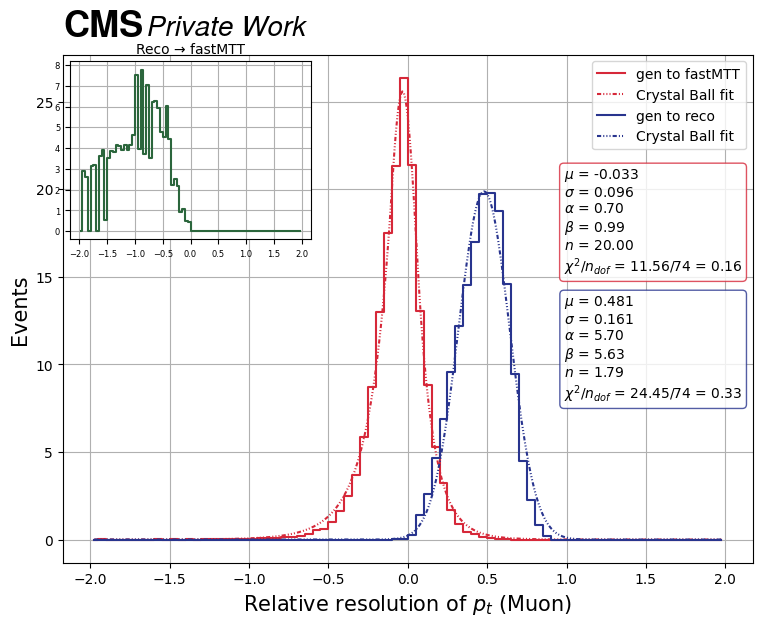

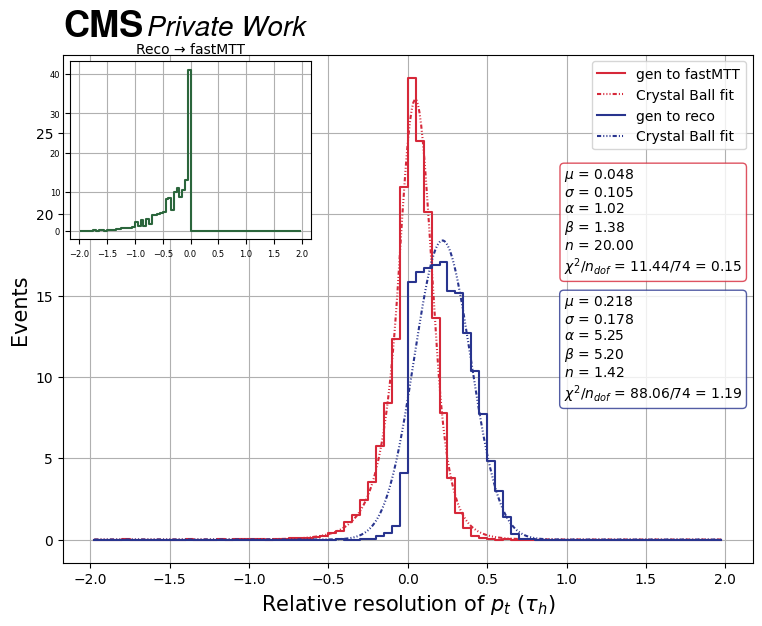

In [118]:
# Resolutionsarten und Rekonstruktionsschritte
res_types = ["abs", "rel"]
reco_steps = [ "gen_to_fastMTT", "gen_to_reco", "reco_to_fastMTT"]

step_info = {
    "gen_to_reco": {
        "colour": "#28348e",  # blau
        "linestyle": "solid"                         #"linestyle": (0, (2, 2)) # gestrichelt
    },
    "reco_to_fastMTT": {
        "colour": "#2b663c",  # grün
        "linestyle": "solid"                         #"linestyle": (0, (2, 1, 0.5, 1, 0.5, 1, 0.5, 1))  # komplex gestrichelt
    },
    "gen_to_fastMTT": {
        "colour": "#d62839",  # rot
        "linestyle": "solid"
    }
}

fit_info = {
    "gen_to_reco": {
        "colour": "#28348e",  # blau
        "linestyle": (0, (2, 1, 0.5, 1, 0.5, 1, 0.5, 1)),
        "x_pos": 0.985, # left side 0.775,
        "y_pos": 0.53,
    },
    "reco_to_fastMTT": {
        "colour": "#2b663c",  # grün
        "linestyle": (0, (2, 1, 0.5, 1, 0.5, 1, 0.5, 1)),
    },
    "gen_to_fastMTT": {
        "colour": "#d62839",  # rot
        "linestyle": (0, (2, 1, 0.5, 1, 0.5, 1, 0.5, 1)),
        "x_pos": 0.985, # left side 0.775,
        "y_pos": 0.78,
    }
}



# Pfad zu deinen .pickle-Dateien
#reco_version = "fastMTT_4MeV/"
reco_version = "fastMTT_0p1_m_H/"
base_path = os.path.join("INPUT", "resolutions", reco_version)
combined_path = os.path.join(base_path, "combined_pickles")
os.makedirs(combined_path, exist_ok=True)

# Alle numerischen Unterordner (z. B. "1", "2", "3")
subfolders = ["1", "2", "3"]

# Dictionary zur Gruppierung nach (res_type, reco_step, observable)
file_groups = defaultdict(list)

# Alle Pickle-Dateien aus den Unterordnern einsammeln
for folder in subfolders:
    folder_path = os.path.join(base_path, folder)
    
    for fname in os.listdir(folder_path):
        if fname.endswith(".pickle") and re.match(r"hist__hcand_resolution_.*\.pickle", fname):
            match = re.match(r"hist__hcand_resolution_(rel|abs)__(.*?)__(.+)\.pickle", fname)
            if match:
                res_type, reco_step, observable = match.groups()
                key = (res_type, reco_step, observable)
                full_path = os.path.join(folder_path, fname)
                file_groups[key].append(full_path)

# Histogramme kombinieren
for (res_type, reco_step, observable), files in file_groups.items():
    if len(files) < 2:
        print(f"[!] Weniger als zwei Dateien für: {res_type}, {reco_step}, {observable}")
        continue

    hist_combined = None

    for filepath in sorted(files):
        with open(filepath, "rb") as f:
            hist = pickle.load(f)
            if hist_combined is None:
                hist_combined = hist
            else:
                hist_combined += hist

    # Speichern
    outname = f"hist__hcand_resolution_{res_type}__{reco_step}__{observable}.pickle"
    outpath = os.path.join(combined_path, outname)

    with open(outpath, "wb") as f_out:
        pickle.dump(hist_combined, f_out)

    #print(f"[✓] Kombiniert und gespeichert: {outname}")




# Gruppierung der Dateien nach observable und lepton (z.B. pt_1)
grouped_files = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# Alle pickle-Dateien sammeln und nach den entsprechenden Kategorien gruppieren
for filename in os.listdir(combined_path):
    if filename.endswith(".pickle"):
        #print(f"Processing file: {filename}")
        
        parts = filename.replace(".pickle", "").split("__")
        #print(f"Parts: {parts}")  # Überprüfen, wie die Datei aufgeteilt wird

        if len(parts) != 4:
            #print(f"⚠️ Skipping unexpected file format: {filename}")
            continue

        # Teile der Datei extrahieren
        resolution = parts[1]  # z.B. hcand_resolution_abs
        step = parts[2]        # z.B. gen_to_fastMTT
        observable_lepton = parts[3].replace(".pickle", "")  # z.B. eta_1
        
        # Res_type extrahieren (abs oder rel)
        if 'abs' in resolution:
            res_type = 'abs'
        elif 'rel' in resolution:
            res_type = 'rel'
        else:
            res_type = 'unknown'

        full_path = os.path.join(combined_path, filename)

        # Dateien nach observable_lepton, res_type und step gruppieren
        grouped_files[observable_lepton][res_type][step].append(full_path)

# Plotten
output_base = "OUTPUT/resolutions/"
output_dir = os.path.join(output_base, reco_version)
os.makedirs(output_dir, exist_ok=True)

# Für jede Kombination von observable_lepton und res_type
for observable_lepton, res_group in grouped_files.items():
    for res_type, step_dict in res_group.items():
        
        # Starte eine neue Figur für diese observable_lepton + res_type Kombination
        fig, ax = plt.subplots(figsize=(8.9, 6.6))
        hep.cms.text("Private Work", loc=0, pad=0.02, fontsize=20)

        #plt.tight_layout()
        inset_ax = inset_axes(ax, width="35%", height="35%", loc='upper left')  # kleines Fenster

        # Liste, um zu prüfen, ob etwas geplottet wurde
        plotted_main = False
        plotted_inset = False

        for step in reco_steps:
            if step in step_dict:
                for file_path in step_dict[step]:
                    with open(file_path, "rb") as f:
                        hist = pickle.load(f)

                        # Get the IntCategory axis
                        category_axis = hist.axes[0]
                        category_values = category_axis.edges

                        # Collect indices where the value starts with "2001"
                        selected_indices = []
                        zahl = 2001  # Beispiel, um mit 2001 zu filtern

                        # Iterate with explicit access
                        for i in range(len(category_axis)):
                            cat = category_axis[i]
                            #print(f"  Index {i}: {cat}")
    
                            # Convert to string (after forcing to int if it's float-like)
                            cat_str = str(int(cat)) if isinstance(cat, float) else str(cat)
                            if cat_str.startswith(f"{zahl}"):
                                selected_indices.append(i)
                                #print("selected_indices : ", selected_indices)

                        # Extrahiere die Bin-Grenzen und Werte
                        bin_values = hist.values()
                        bin_variances = hist[17, 0, 0, :].variances() ** 0.5

                        if bin_values.ndim > 1:
                            bin_values = hist.values()[17, 0, 0, :] 
                            bin_variances = hist.variances()[17, 0, 0, :] ** 0.5

                        bin_edges = hist.axes[3].edges
                        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

                        #for x, y in zip(bin_centers, bin_values):
                        #    print(f"x = {x:.2f}, y = {y:.3f}")


                    # Wenn der Schritt "gen" im Namen enthält, plotte auf dem Hauptplot
                    label = step.replace("_", " ")
                    style = step_info[step]
                    fit_style = fit_info[step]
                    if "gen" in step:
                        ax.step(bin_centers, bin_values, where='mid', label=label, color=style["colour"], linestyle=style["linestyle"])
                        plotted_main = True
                        # Nur fitten, wenn genügend Werte, relative Verteilung und Momentum als Observable
                        if observable_lepton.startswith("p") and not observable_lepton.startswith("ph") and res_type == 'rel':
                            try:
                                # Erst grob initialisieren
                                N_init = np.max(bin_values)
                                mu_init = bin_centers[np.argmax(bin_values)]
                                sigma_init = np.std(bin_centers) / 5
                                alpha_init = 2.0  # Startwert für alpha
                                beta_init = 2.0   # Startwert für beta
                                n_init = 3 
                                
                                p0 = [alpha_init, beta_init, n_init, mu_init, sigma_init, N_init]
                                bounds = (
                                        [0.1, 0.1, 1.01, mu_init - 1.0, 0.01, 0.1],  # untere Grenzen
                                        [10.0, 10.0, 20.0, mu_init + 1.0, 2.0, 10 * N_init]  # obere Grenzen
                                    )

                                # Fit durchführen
                                popt, pcov = curve_fit(crystal_ball, bin_centers, bin_values, p0=p0, bounds=bounds)
                                alpha, beta, n, mu, sigma, N = popt

                                # 2. Maske anwenden, um Division durch Null zu vermeiden
                                mask_0_fit = bin_values > 0
                                mask_0 = bin_variances > 0
                                
                                # Fit-Kurve erzeugen
                                x_fit = np.linspace(min(bin_centers), max(bin_centers), 5*len(bin_centers))
                                #x_fit = np.linspace(min(bin_centers[mask_0_fit]), max(bin_centers[mask_0_fit]), 5*len(bin_centers))
                                y_fit = crystal_ball(x_fit, *popt)

                                # Bin-Werte (beobachtet) und Fit-Werte (erwartet)
                                observed = bin_values
                                #x_fit_80 = np.linspace(min(bin_centers[mask_0_fit]), max(bin_centers[mask_0_fit]), len(bin_centers))
                                x_fit_80 = np.linspace(min(bin_centers), max(bin_centers), len(bin_centers))
                                expected = crystal_ball(x_fit_80, *popt)
                                # Normiere die erwarteten Werte, um sicherzustellen, dass ihre Summe der Summe der beobachteten Werte entspricht
                                expected = expected * np.sum(observed) / np.sum(expected)

                                
                                # Berechnung von Chi² und p-Wert
                                #chi2, p_value = stats.chisquare(observed, expected)

                                observed = observed.flatten()
                                expected = expected.flatten()
                                bin_variances = bin_variances.flatten()
                                
                                # 3. Chi² nur auf gültige Bins berechnen
                                #chi2 = np.sum(((observed[mask_0] - expected[mask_0]) / bin_variances[mask_0]) ** 2)
                                #chi2 = np.sum(((observed - expected) / bin_variances) ** 2)
                                chi2 = np.sum((observed - expected) ** 2)
                                
                                # 4. Anzahl der Freiheitsgrade (ndof)
                                #ndof = np.sum(mask_0) - len(popt)  # popt sind Fit-Parameter 
                                ndof = len(observed) - len(popt)

                                chi2_ndof = chi2 / ndof
                                
                                
                                                                
                                # Berechnung der Freiheitsgrade
                                #ndof = len(observed) - len(popt)  # Anzahl der Datenpunkte minus Anzahl der Parameter

                                
                                # Fit plotten
                                ax.plot(x_fit, y_fit, color=fit_style["colour"], linestyle=fit_style["linestyle"], label="Crystal Ball fit")
                        
                                # Statistikbox vorbereiten
                                fit_text = (
                                    f"$\\mu$ = {mu:.3f}\n"
                                    f"$\\sigma$ = {sigma:.3f}\n"
                                    f"$\\alpha$ = {alpha:.2f}\n"
                                    f"$\\beta$ = {beta:.2f}\n"
                                    f"$n$ = {n:.2f}\n"
                                    f"$\\chi^2/n_{{dof}}$ = {chi2:.2f}/{ndof:.0f} = {chi2_ndof:.2f}"
                                )
                        
                                # Box einfügen
                                ax.text(
                                    fit_style["x_pos"], fit_style["y_pos"], fit_text,
                                    transform=ax.transAxes,
                                    fontsize=10,
                                    verticalalignment='top', #box alignment
                                    horizontalalignment='right', #box alignment
                                    multialignment='left', #text alignment
                                    bbox=dict(boxstyle="round", facecolor='white', alpha=0.8, edgecolor=fit_style["colour"]) #, linestyle=fit_style["linestyle"])
                                )
                            except RuntimeError:
                                print(f"⚠️ Crystal Ball fit failed for {observable_lepton}, step: {step}")
                    elif step == "reco_to_fastMTT":
                        # Plotten des Inset für "reco_to_fastMTT"
                        inset_ax.step(bin_centers, bin_values, where='mid', label=label, color=style["colour"], linestyle=style["linestyle"])
                        plotted_inset = True

        # Plot-Details hinzufügen
        if plotted_main:
            # Zerlege observable_lepton in observable und lepton
            try:
                observable, lepton_index = observable_lepton.split("_")
            except ValueError:
                print(f"⚠️ Unexpected format in observable_lepton: {observable_lepton}")
                observable = observable_lepton
                lepton_index = ""

            # Setze das Observable im LaTeX-Format
            if observable == "eta":
                observable_latex = r"$\eta$"
            elif observable == "phi":
                observable_latex = r"$\varphi$"
            elif observable.startswith("p"):
                if observable in ["px", "py", "pz", "pt"]:
                    subscript = observable[1:]  # Nimm den Teil nach "p", z.B. "x", "y", "z", "t"
                    observable_latex = rf"$p_{{{subscript}}}$"
                else:
                    observable_latex = r"$p$"
            else:
                observable_latex = observable  # fallback, z. B. "mass", "E", etc.
            
            # Setze das Lepton
            if lepton_index == "1":
                lepton_latex = "Muon"
            elif lepton_index == "2":
                lepton_latex = r"$\tau_h$"
            else:
                lepton_latex = ""

            # Setze das Resolutionstyp-Wort
            res_type_name = "Absolute" if res_type == "abs" else "Relative"
            
            # Zusammensetzen des vollständigen y-Achsen-Titels
            xlabel = rf"{res_type_name} resolution of {observable_latex} ({lepton_latex})"
                
            #ax.set_title(f"{observable_lepton} {res_type}", fontsize=15)
            #ax.set_xlabel("Resolution" if res_type == "abs" else "Relative resolution", fontsize=15)
            ax.set_xlabel(xlabel, fontsize=15)
            ax.set_ylabel("Events", fontsize=15)
            ax.grid(True)
            ax.legend()


        # Inset-Plot-Details
        if plotted_inset:
            inset_ax.set_title("Reco → fastMTT", fontsize=10)
            inset_ax.tick_params(axis='both', which='major', labelsize=6)
            #inset_ax.legend(loc='best', fontsize=8)
            inset_ax.grid(True)

        # Plot speichern
        save_name = f"{observable_lepton}_{res_type}_resolutions_cryt.pdf"
        plt.savefig(os.path.join(output_dir, save_name), dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()  # Optional, um den Plot zu schließen und Speicher zu sparen


In [100]:
# 1. Sicherstellen, dass alle Arrays 1D sind
observed = observed.flatten()
expected = expected.flatten()
errors = errors.flatten()

# 2. Maske anwenden, um Division durch Null zu vermeiden
mask = errors > 0

# 3. Chi² nur auf gültige Bins berechnen
chi2 = np.sum(((observed[mask] - expected[mask]) / errors[mask]) ** 2)

# 4. Anzahl der Freiheitsgrade (ndof)
ndof = np.sum(mask) - len(popt)  # popt sind Fit-Parameter

print(f"Step : {step}, Chi²: {chi2:.3f}, ndof: {ndof}")


Step : reco_to_fastMTT, Chi²: 303.432, ndof: 31


In [79]:
# Get the IntCategory axis
category_axis = hist.axes[0]
category_values = category_axis.edges

# Collect indices where the value starts with "2001"
selected_indices = []
zahl = 2001  # Beispiel, um mit 2001 zu filtern

# Iterate with explicit access
for i in range(len(category_axis)):
    cat = category_axis[i]
    #print(f"  Index {i}: {cat}")

    # Convert to string (after forcing to int if it's float-like)
    cat_str = str(int(cat)) if isinstance(cat, float) else str(cat)
    if cat_str.startswith(f"{zahl}"):
        selected_indices.append(i)
        #print("selected_indices : ", selected_indices)

# Extrahiere die Bin-Grenzen und Werte
#bin_values = hist.values()
#bin_values = hist.values()[17, 0, 0, :]
bin_values = hist[17, 0, 0, :].values()
bin_variances = hist[17, 0, 0, :].variances() ** 0.5

#errors = (data[category_axis.index(cval), :, shift_index, :].variances()) ** 0.5
                            

bin_edges = hist.axes[3].edges
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

In [80]:
bin_values

array([0.00000000e+00, 2.26466337e-02, 1.34829052e-01, 0.00000000e+00,
       1.45832516e-01, 2.01190685e-01, 0.00000000e+00, 1.96215607e-01,
       3.27774565e-01, 6.59354530e-02, 2.76399620e-01, 4.08944095e-01,
       4.07967869e-01, 6.83882832e-01, 6.39213601e-01, 7.13774322e-01,
       8.35631049e-01, 7.26896156e-01, 8.55730630e-01, 1.00439570e+00,
       2.28826339e+00, 1.23918395e+00, 2.90447898e+00, 1.42562089e+00,
       3.21379871e+00, 1.81244035e+00, 4.02696416e+00, 4.15256015e+00,
       4.43085852e+00, 4.64095605e+00, 4.93507132e+00, 8.16656340e+00,
       8.37477826e+00, 5.49310063e+00, 9.96676982e+00, 1.10577868e+01,
       8.61655031e+00, 1.04199305e+01, 1.31389971e+01, 4.11711401e+01,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [82]:
bin_variances

array([0.        , 0.01880738, 0.03309203, 0.        , 0.02926695,
       0.03831205, 0.        , 0.04007438, 0.0485997 , 0.02189533,
       0.04610137, 0.05645929, 0.05649208, 0.06447544, 0.06662663,
       0.06910257, 0.07255894, 0.07020159, 0.08103939, 0.08696298,
       0.12517816, 0.09356946, 0.14142201, 0.09425764, 0.14602983,
       0.11063512, 0.16394883, 0.16827388, 0.17286415, 0.17429288,
       0.18388215, 0.2469412 , 0.24196975, 0.18828766, 0.37379814,
       0.27972252, 0.27360682, 0.25926873, 0.29830169, 0.52028592,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [214]:
catdict = {
    r"$\mu a^{3p}_{1}$" : 20014008,
}

shiftdict = {
    "cp_maxmix": {"shift": 0, "colour": "#2b663c", "location": "lower right", "linestyle":(0, (2, 1, 0.5, 1, 0.5, 1, 0.5, 1))},
}

# Beispiel für das Laden der Daten
with open(file_path, 'rb') as fileptr:
    data = pickle.load(fileptr)
    print("data : ", data)


# Achseninformationen extrahieren
axes = data.axes
category_axis = axes['category']
shift_axis = axes['shift']

# cparray wird für die Speicherung von Werten und Fehlern verwendet
cparray = {}

# Iteration über die Kategorien und Hypothesen
for ccat, cval in catdict.items():
    for shift, props in shiftdict.items():
        print("ccat, cval ", ccat, cval)
        hypothesis = shift
        colour = props["colour"]
        location = props["location"]
        linestyle = props["linestyle"]

        # Prüfen, ob die Kategorie in den Achsen vorhanden ist
        if cval not in category_axis:
            print(f"WARNING : {cval} not in categories")
            continue

        # Finden des Indexes der Verschiebung (shift) auf der Shift-Achse
        shift_index = shift_axis.index(props["shift"])

        # Werte aus den Daten extrahieren
        values = data[category_axis.index(cval), :, shift_index, :].values()

        # Fehler (Varianz) extrahieren und durch Quadratwurzel die Standardabweichung berechnen
        errors = (data[category_axis.index(cval), :, shift_index, :].variances()) ** 0.5

        # Speichern der Ergebnisse im cparray
        if ccat not in cparray:
            cparray[ccat] = {}

        if hypothesis not in cparray[ccat]:
            cparray[ccat][hypothesis] = {
                "values": values,
                "errors": errors,
                "colour": colour,
                "location": location,
                "linestyle": linestyle
            }
        else:
            # Falls die Hypothese bereits existiert, addiere die neuen Werte zu den bestehenden
            cparray[ccat][hypothesis]["values"] += values
            # Kombiniere Fehlerquadrate (Root Sum of Squares)
            cparray[ccat][hypothesis]["errors"] = (cparray[ccat][hypothesis]["errors"]**2 + errors**2) ** 0.5


data :  Hist(
  IntCategory([200000, 1e+06, 3e+06, 15000, 2.0014e+07, 4e+07, 300000, 13000, 3, 21, 1e+07, 2.0014e+07, 11000, 16000, 10000, 5, 23, 2.0014e+07, 2.0014e+07, 9000, 1, 15, 13, 100000, 25, 9, 27, 7, 31, 37, 6000, 33, 12000, 2.0014e+07, 11, 3000, 2000, 19, 17, 35, 8000, 39, 7000, 4000, 29, 1000, 5000, 2e+06, 4e+06], growth=True, name='category'),
  IntCategory([11100], growth=True, name='process'),
  IntCategory([0], growth=True, name='shift'),
  Variable(array([-0.2  , -0.195, -0.19 , -0.185, -0.18 , -0.175, -0.17 , -0.165,
       -0.16 , -0.155, -0.15 , -0.145, -0.14 , -0.135, -0.13 , -0.125,
       -0.12 , -0.115, -0.11 , -0.105, -0.1  , -0.095, -0.09 , -0.085,
       -0.08 , -0.075, -0.07 , -0.065, -0.06 , -0.055, -0.05 , -0.045,
       -0.04 , -0.035, -0.03 , -0.025, -0.02 , -0.015, -0.01 , -0.005,
        0.   ,  0.005,  0.01 ,  0.015,  0.02 ,  0.025,  0.03 ,  0.035,
        0.04 ,  0.045,  0.05 ,  0.055,  0.06 ,  0.065,  0.07 ,  0.075,
        0.08 ,  0.085,  0.09 ,  0.

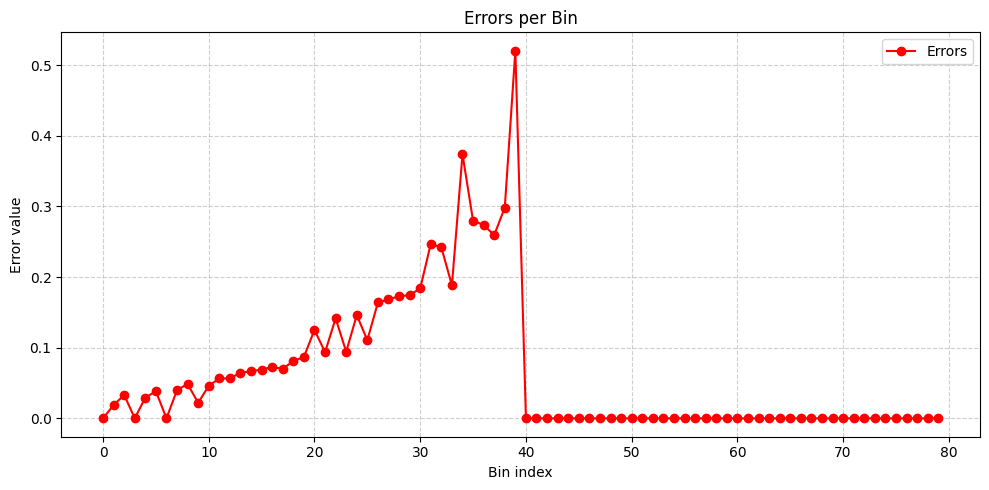

In [27]:
# Flatten the array to 1D
errors_flat = errors.flatten()

# Create x values (bin indices or bin centers)
x = np.arange(len(errors_flat))

# Plot the errors
plt.figure(figsize=(10, 5))
plt.plot(x, errors_flat, marker='o', linestyle='-', color='red', label='Errors')
plt.xlabel("Bin index")
plt.ylabel("Error value")
plt.title("Errors per Bin")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()